In [1]:
import random 
import gym
import numpy as np
import collections
from tqdm import tqdm
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import rl_utils

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
class ReplayBuffer:
    def __init__(self,capacity):
        self.buffer = collections.deque(maxlen=capacity)
    def add(self,state,action,reward,next_state,done):
        self.buffer.append((state,action,reward,next_state,done))
    def sample(self,batch_size):
        transitions = random.sample(self.buffer,batch_size)
        state,action,reward,next_state,done = zip(*transitions)
        return np.array(state),action,reward,np.array(next_state),done
    def size(self):
        return len(self.buffer)

In [3]:
class Qnet(torch.nn.Module):
    def __init__(self,state_dim,hidden_dim,action_dim):
        super().__init__()
        self.fc1 = torch.nn.Linear(state_dim,hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim,action_dim)
    def forward(self,x):
        x =  F.relu(self.fc1(x))
        return self.fc2(x)

In [4]:
class DQN:
    def __init__(self,state_dim,
                 hidden_dim,
                 action_dim,
                 learning_rate,
                 gamma,
                 epsilon,
                 target_update,
                 device):
        self.action_dim = action_dim
        self.q_net = Qnet(state_dim=state_dim,
                          hidden_dim=hidden_dim,
                          action_dim=self.action_dim).to(device=device)
        self.target_q_net = Qnet(state_dim=state_dim,
                                 hidden_dim=hidden_dim,
                                 action_dim=self.action_dim).to(device=device)
        self.optimizer = torch.optim.Adam(self.q_net.parameters(),lr=learning_rate)
        self.gamma = gamma
        self.epsilon = epsilon
        self.target_update = target_update
        self.count = 0
        self.device = device
    def take_action(self,state):
        if np.random.random() < self.epsilon:
            action = np.random.randint(self.action_dim)
        else:
            state = torch.tensor([state],dtype=torch.float).to(device=self.device)
            action  = self.q_net(state).argmax().item()
        return action
    def update(self,transition_dict):
        states = torch.tensor(transition_dict["states"],dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict["actions"]).view(-1,1).to(self.device)
        rewards = torch.tensor(transition_dict["rewards"],dtype=torch.float).view(-1,1).to(self.device)
        next_states = torch.tensor(transition_dict["next_states"],dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict["dones"],dtype=torch.float).view(-1,1).to(self.device)


        q_values = self.q_net(states).gather(1,actions)
        max_next_q_values = self.target_q_net(next_states).max(1)[0].view(-1,1)
        q_targets = rewards + self.gamma*max_next_q_values*(1-dones)
        dqn_loss = torch.mean(F.mse_loss(q_values,q_targets)) 
        self.optimizer.zero_grad()
        dqn_loss.backward()
        self.optimizer.step()

        if self.count%self.target_update == 0:
            self.target_q_net.load_state_dict(self.q_net.state_dict())
        self.count+=1

In [5]:
lr = 3e-3              
num_episodes = 500
hidden_dim = 128
gamma = 0.98
target_update = 10      
epsilon = 0.01          
buffer_size = 10000
minimal_size = 500
batch_size = 64
device = "cuda"

env_name = "CartPole-v0"
env = gym.make(env_name)
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
replaybuffer = ReplayBuffer(buffer_size)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = DQN(state_dim=state_dim,
            hidden_dim=hidden_dim,
            action_dim=action_dim,
            learning_rate=lr,
            gamma=gamma,
            epsilon=epsilon,
            target_update=target_update,device=device)
state_dim,action_dim

/home/ricaedo/下载/yes/envs/AutoGluon/lib/python3.9/site-packages/gym/envs/registration.py:555: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(


(4, 2)

In [6]:
return_list = []
for i in range(10):
    with tqdm(total=int(num_episodes/10),desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes/10)):
            episode_return = 0
            state,_ = env.reset()
            done = False
            while not done:
                action = agent.take_action(state)
                next_state, reward, done, truncated, _ = env.step(action)
                done = done or truncated
                replaybuffer.add(state,action,reward,next_state,done)
                state = next_state
                episode_return += reward
                if replaybuffer.size() > minimal_size:
                    b_s,b_a,b_r,b_ns,b_d = replaybuffer.sample(batch_size)
                    transition_dict = {
                        'states':b_s,
                        "actions":b_a,
                        'rewards':b_r,
                        'dones':b_d,
                        'next_states':b_ns
                    }
                    agent.update(transition_dict)
            return_list.append(episode_return)
            if (i_episode+1)%10 == 0:
                pbar.set_postfix({'episode':'%d'%(num_episodes/10 * i + i_episode + 1),'return':'%.3f'%np.mean(return_list[-10:])})
            pbar.update(1)

Iteration 0:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_10053/1344690870.py:27: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  state = torch.tensor([state],dtype=torch.float).to(device=self.device)
Iteration 9: 100%|██████████| 50/50 [00:12<00:00,  3.98it/s, episode=500, return=49.500] 


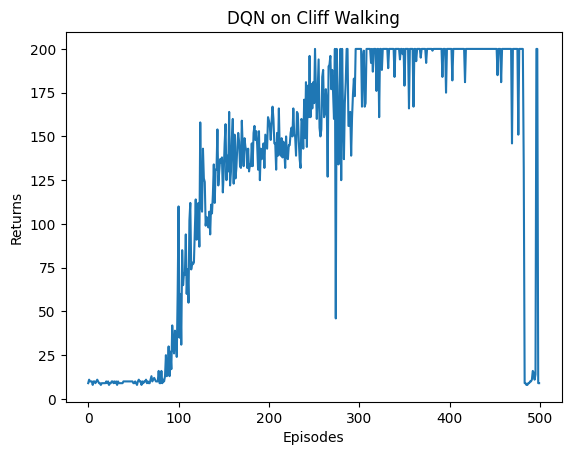

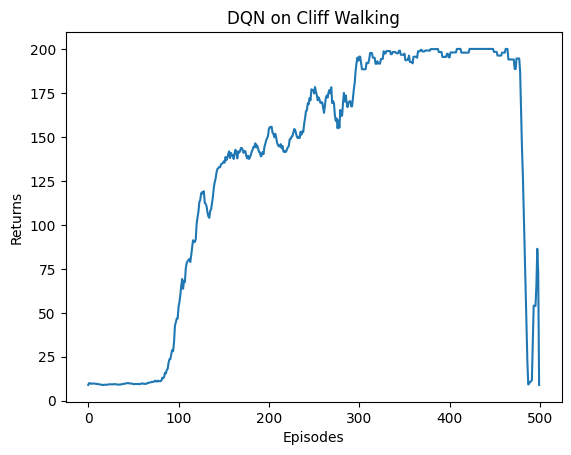

In [7]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list,return_list)
plt.xlabel("Episodes")
plt.ylabel('Returns')
plt.title('DQN on {}'.format('Cliff Walking'))
plt.show()

mv_return = rl_utils.moving_average(return_list,9)
plt.plot(episodes_list,mv_return)
plt.xlabel("Episodes")
plt.ylabel('Returns')
plt.title('DQN on {}'.format('Cliff Walking'))
plt.show()